<a href="https://colab.research.google.com/github/sirhylle/notebooks/blob/main/tuto_llm_to_agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # HANDS-ON CIO : De l'IA Générative à l'IA Agentique



 **Objectif :** Visualiser la mécanique simplifiée d'accès à un modèle et ses modalités d'utilisation.

 **Stack Technique :** OpenAI pour l'API LLM + la librairie LangChain pour orchestrer.

 **Durée :** 30 à 60 min



 ---



 ## ÉTAPE 0 : Initialisation de l'environnement

 Nous installons les connecteurs nécessaires pour piloter l'IA depuis du code Python.

In [59]:
# Installation des librairies
# (OpenAI pour le LLM, LangChain pour l'orchestration, FAISS pour la recherche)

print("⚙️ Installation des librairies en cours... cela peut prendre 30s.")
!pip install -q langchain langchain-openai langgraph faiss-cpu duckduckgo-search langchain_community --quiet

import os
from google.colab import userdata
from langchain_openai import ChatOpenAI

print("✅ Librairies installées avec succès.")


# Récupération d'une clé API via l'environnement Colab

try:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
    print("🔑 Clé API récupérée depuis le coffre-fort Colab.")
except Exception as e:
    print("⚠️ ERREUR : Avez-vous bien ajouté le secret 'OPENAI_API_KEY' dans le menu de gauche ?")

⚙️ Installation des librairies en cours... cela peut prendre 30s.
✅ Librairies installées avec succès.
🔑 Clé API récupérée depuis le coffre-fort Colab.


Nous instancions l'accès au LLM : ici ce sera *gpt-4o-mini* avec la plupart de ses paramètres par défaut.

In [60]:
# Initialisation du modèle 'GPT-4o-mini'
# `temperature=0` : L'IA est délibérément moins "créative" pour des réponses factuelles.
# (Augmentez à 0.5, 1, voire 2 pour plus d'originalité !)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("✅ Moteur IA connecté et prêt.")

✅ Moteur IA connecté et prêt.


 ---

 ## MODULE 1 : Le LLM seul



 Dans cette première étape, nous interrogeons le modèle brut.

 Il a lu tout Wikipédia, mais il ne connaît **pas** notre entreprise.



 **Action :** Exécutez la cellule pour voir sa réponse par défaut.

In [61]:
from langchain_core.prompts import ChatPromptTemplate

# 🌟 Étape 1 : Définition du "Persona" de l'IA (Qui est-elle ?)
# {input} veut dire que le texte en question sera injecté plus tard.
prompt_chat = ChatPromptTemplate.from_messages([
    ("system", "Tu es un assistant assurance serviable et très concis."),
    ("human", "{input}")
])

# 🔗 Étape 2 : Connexion du prompt au modèle LLM
chain = prompt_chat | llm

# 🎯 Étape 3 : Une question test (l'IA ne sait pas spécialement de quoi on parle, produit, couverture, etc.)
question = "Mon aquarium de 300L a explosé dans mon salon. Suis-je couvert ?"

# on valorise {input} avec notre question
print("🤖 [IA] Réflexion...")
reponse = chain.invoke({"input": question})
print(f"RÉPONSE :\n{reponse.content}")

🤖 [IA] Réflexion...
RÉPONSE :
Cela dépend de votre contrat d'assurance habitation. En général, les dommages causés par un aquarium peuvent être couverts si vous avez une garantie "dommages aux biens". Vérifiez les conditions spécifiques de votre police ou contactez votre assureur pour plus de détails.


 > **Constat :** L'IA répond de manière plausible mais elle n'a aucun contexte spécifique.

 > **Experimentez :** Remarquez qu'à chaque appel la réponse est EXACTEMENT la même, c'est lié à la température 0.
 Vous pouvez réexécuter la cellule précedente avec une température de 1.5 et remarquer qu'entre plusieurs appels la réponse va très légèrement changer.

In [62]:
# 💬 Bonus : Pour une conversation complète, tout l'historique des messages
# est envoyé à chaque fois au LLM. Il fonctionne "sans état" et vise à
# compléter la discussion en conservant la logique précédente.

prompt_chat = ChatPromptTemplate.from_messages([
    ("system", "Tu es un assistant IA, ton nom est CIVA, nous sommes aujourd'hui le jeudi 5 février 2026."),
    ("human", "Hello! Je m'appelle Philippe."),
    ("ai", "Bonjour Philippe, enchanté, je m'appelle CIVA."),
    ("human", "Je viens de casser mon aquarium hier, hélas."),
    ("ai", "Désolé de l'apprendre."),
    ("human", "Je l'ai cassé quel jour de la semaine déjà ?")
])
chain = prompt_chat | llm

reponse = chain.invoke({})
print(f"RÉPONSE :\n{reponse.content}")

RÉPONSE :
Hier était le mercredi 4 février 2026, donc tu as cassé ton aquarium un mercredi.


In [63]:
# 💬 Bonus : Vous pouvez contruire artificiellement l'historique
# pour faire comprendre quel comportement vous attendez.
# Le LLM va chercher à compléter la suite de façon cohérente
# même s'il n'est pas réellement  à l'origine des réponses précédentes.

prompt_chat = ChatPromptTemplate.from_messages([
    ("human", "A"),
    ("ai", "1"),
    ("human", "B"),
    ("ai", "2"),
    ("human", "C")
])
chain = prompt_chat | llm

reponse = chain.invoke({})
print(f"RÉPONSE :\n{reponse.content}")

RÉPONSE :
3


 ---

 ## MODULE 2 : Le RAG (L'Expert Documenté)



 Pour rendre l'IA exploitable, nous pouvons lui donner accès à des documents (Ex : des Conditions Générales).

 C'est le principe du **RAG** (Retrieval Augmented Generation).

In [64]:
# Préparation des outils de recherche documentaire
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

# Nous utilisons le modèle d'embeddings d'OpenAI pour transformer le texte en vecteurs mathématiques
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("✅ Moteur d'indexation prêt.")

✅ Moteur d'indexation prêt.


 ### Étape 2.1 : Indexation des connaissances

 Nous simulons ici une base de connaissance interne avec une règle stricte : **Exclusion pour un contrat d'assurance habitation des dégats des aquariums au-delà de 200 Litres**.
 Pour compliquer un peu les choses nous décrivons deux produits différents avec des petites nuances.

In [65]:
# Vos règles métier (simulées)
documents_metier = [
    "CONTRAT HABITATION ESSENTIEL - Art 1 : Les dégâts des eaux sont couverts.",
    "CONTRAT HABITATION ESSENTIEL - Art 2 : EXCLUSION FORMELLE des aquariums de plus de 200 Litres.",
    "CONTRAT HABITATION ESSENTIEL - Art 3 : Franchise sinistre fixe de 250€.",
    "CONTRAT HABITATION PLUS - Art 1 : Les dégâts des eaux sont couverts.",
    "CONTRAT HABITATION PLUS - Art 2 : EXCLUSION FORMELLE des aquariums de plus de 500 Litres.",
    "CONTRAT HABITATION PLUS - Art 3 : Franchise sinistre fixe de 300€.",
]

# Création du moteur de recherche vectoriel (Indexation)
vectorstore = FAISS.from_texts(documents_metier, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

print(f"📚 {len(documents_metier)} règles métier ont été indexées dans la mémoire.")


📚 6 règles métier ont été indexées dans la mémoire.


 ### Étape 2.2 : Interrogation avec le contexte

 Nous reposons notre question à propos de l'aquarium cassé. Le système va d'abord chercher l'info, puis répondre via l'IA.

In [66]:
# Le Template de prompt
# utilise deux variables : context et question
template_rag = """Tu es un expert assurance.
Règle : Réponds UNIQUEMENT en te basant sur ce contexte :
{context}

Question : {question}
"""
prompt_rag = ChatPromptTemplate.from_template(template_rag)

# La question que nous allons tester
question_client = "Mon aquarium de 300L a fui. Rembourse-moi !"
print(f"1️⃣ QUESTION UTILISATEUR : {question_client}\n")

# ------------------
# LE RAG en 3 étapes
# ------------------

# ÉTAPE A : La Recherche (Retrieval)
# On demande à la base vectorielle de trouver les morceaux de textes les plus pertinents
docs_retrouves = retriever.invoke(question_client)
contexte_texte = "\n".join([d.page_content for d in docs_retrouves])

print(f"2️⃣ CITATIONS TROUVÉES (RAG) :")
print(f"---\n{contexte_texte}\n---\n")

# ÉTAPE B : La Construction du Prompt (L'Augmentation, par le contexte)
# On fusionne le template + le contexte trouvé + la question
prompt_final = prompt_rag.invoke({"context": contexte_texte, "question": question_client})

print("3️⃣ LE PROMPT RÉEL ENVOYÉ AU LLM :")
print("==================================================")
print(prompt_final.to_string())
print("==================================================\n")

# ÉTAPE C : La Génération
# On envoie ce prompt complet au LLM
print("4️⃣ RÉPONSE DE L'IA :")
reponse = llm.invoke(prompt_final)
print(reponse.content)

1️⃣ QUESTION UTILISATEUR : Mon aquarium de 300L a fui. Rembourse-moi !

2️⃣ CITATIONS TROUVÉES (RAG) :
---
CONTRAT HABITATION ESSENTIEL - Art 2 : EXCLUSION FORMELLE des aquariums de plus de 200 Litres.
---

3️⃣ LE PROMPT RÉEL ENVOYÉ AU LLM :
Human: Tu es un expert assurance.
Règle : Réponds UNIQUEMENT en te basant sur ce contexte :
CONTRAT HABITATION ESSENTIEL - Art 2 : EXCLUSION FORMELLE des aquariums de plus de 200 Litres.

Question : Mon aquarium de 300L a fui. Rembourse-moi !


4️⃣ RÉPONSE DE L'IA :
D'après l'Article 2 de votre contrat d'assurance habitation essentiel, les aquariums de plus de 200 litres sont formellement exclus de la couverture. Par conséquent, je ne peux pas vous rembourser pour les dommages causés par la fuite de votre aquarium de 300 litres.


 > **Constat 1 :** L'IA répond grâce à des extrait de textes de référence qui lui ont été fournis automatiquement. Ils peuvent provenir d'une système de recherche classique (mots clés) ou sémantique (proximité de sens entre le texte et la question) ou d'un appel à une api (recherche de polices).

 > **Constat 2 :** Ici, c'est le recherche sémantique qui est utilisée. Elle a été paramétrée pour ramener 1 seul texte, le plus proche de la question.
 Mais il y avait deux produits différents qui parlaient tous deux d'aquariums. La recherche a ramené l'un plutôt que l'autre, sans raison logique.
 **Une recherche sémantique seule ne garanti pas la cohérence métier de l'information retrouvée.**

 > **Expérimentez :** Changer le paramètre k=1 à k=2 pour ramener les deux textes les plus proches et observez la réponse du LLM.
 Essayez aussi d'ajouter un autre faux document contenant : "Les Aquariums quel bonheur : essai sur le plaisir d'avoir un aquarium et le malheur d'en casser un." et regardez comment le RAG se comporte avec k=1.

 ---

 ## MODULE 3 : L'Agent "Autonome"



 C'est la frontière actuelle de l'IA.

 Nous ne voulons plus seulement qu'elle *réponde* (Chatbot), nous voulons qu'elle *agisse* (Agent).



 Nous allons donner à l'IA des **Outils** (Fonctions Python) et le droit de s'en servir.

 ### Étape 3.1 : Création des Outils

 Nous définissons plusieurs fausses fonctions pour simuler des actions dans le SI
 Elles pourraient représenter des appels à des APIs, etc...

 L'agent aura connaissance de ces fonctions de la même manière qu'il aurait connaissance d'une API :
 il ne connaîtra pas leur code, juste leur signature et leur docstring (le commentaire descriptif)

In [67]:
from langchain.tools import tool
import random

@tool
def get_policies(client_id: str):
    """Récupère la liste des polices d'assurance d'un client."""
    # Simulation : Le client 789 a deux contrats
    return [
        {"policy_id": "POL-GAV-2024", "nom": "Garantie Accidents Vie", "statut": "ACTIF"},
        {"policy_id": "POL-AUTO-2022", "nom": "Assurance Auto", "statut": "ACTIF"}
    ]

@tool
def get_product(policy_id: str):
    """Donne la description marketing du produit."""
    return "Contrat GAV Premium : Couvre les accidents domestiques, chutes, brûlures. Franchise réduite."

@tool
def get_coverage(policy_id: str):
    """⚠️ CRITIQUE : Donne les plafonds et règles de gestion détaillées."""
    if "GAV" in policy_id:
        return """
        Couverture GAV :
        1. Sinistres pour blessure accidentelle : couvert jusqu'à 1000€, avec justificatif médical.
        2. Autres blessures : franchise de 100€ et couvert jusqu'à 300€ sans justificatif.
        """
    return "Règles standard."

@tool
def score_claim(description: str, montant: int):
    """Calcule le score d'acceptation automatique (0-100) basé sur le récit et le montant."""
    # Le piège : un montant élevé fait chuter le score
    if montant > 500:
      print(f"   ⚙️ [Système] Calculated score for {montant}€ is too low for automatic acceptance")
      return {"score": 40}
    print(f"   ⚙️ [Système] Calculated score for {montant}€ is high enough for automatic acceptance")
    return {"score": 90}

@tool
def upload_file(nom_fichier: str):
    """Simule la réception d'un document justificatif."""
    ref = f"DOC-{random.randint(10000,99999)}"
    return f"SUCCÈS : Fichier '{nom_fichier}' reçu et scanné. Réf: {ref}"

@tool
def create_manual_task(policy_id: str, description: str, ref_fichiers: str):
    """Escalade le dossier à un humain (Backoffice)."""
    return f"✅ TÂCHE CRÉÉE [TASK-999]. Un humain va analyser le dossier '{description}' sous 48h."

@tool
def send_money(policy_id: str, montant: int):
    """⚠️ VIREMENT BANCAIRE RÉEL."""
    return f"💸 VIREMENT DE {montant}€ ENVOYÉ SUR LE CONTRAT {policy_id}."

# Liste complète
tools = [get_policies, get_product, get_coverage, score_claim, upload_file, create_manual_task, send_money]


print("✅ Outils connectés à l'IA.")


✅ Outils connectés à l'IA.


In [68]:
# Pour mieux auditer ce que je fera l'IA nous avons aussi besoin d'un petit HELPER

from langchain_core.messages import AIMessage, ToolMessage

def audit_etape(message, debug=True):
    """
    Fonction utilitaire pour décortiquer ce qui se passe dans la tête de l'IA.
    Affiche les appels d'outils, les arguments et les coûts.
    """

    # CAS A : C'est l'IA qui parle ou agit
    if isinstance(message, AIMessage):

        # 1. L'IA décide d'utiliser des outils
        if message.tool_calls:
            for tc in message.tool_calls:
                print(f"\n   🧠 [DÉCISION] Je choisis l'outil : {tc['name']}")
                if debug:
                    print(f"   📝 [ARGS] Données envoyées : {tc['args']}")

        # 2. Audit des coûts (Tokens) - Uniquement en mode Debug
        if debug and message.response_metadata:
            usage = message.response_metadata.get('token_usage', {})
            if usage:
                print(f"   💰 [FINOPS] Coût étape : {usage.get('total_tokens', 0)} tokens")

    # CAS B : C'est le retour technique d'un outil (La fonction répond)
    elif isinstance(message, ToolMessage):
        if debug:
            # On coupe si c'est trop long pour la lisibilité
            preview = (message.content[:100] + '...') if len(message.content) > 100 else message.content
            print(f"   ✅ [RÉSULTAT OUTIL] {preview}")
        else:
            print(f"   ⚙️ [SYSTÈME] Outil terminé.")

 ### Étape 3.2 : Initialisation de l'Agent

 Nous assemblons le "Cerveau" (GPT-4o) et les "Mains" (Tools).

In [69]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

# Le prompt utilisé pour le 1er test
system_prompt = """
Tu es un gestionnaire de sinistre Expert.
Tu discutes avec le client (ID 789 par défaut).

IMPORTANT : Sois empathique et rigoureux.
"""

# Un autre prompt possible, à tester après
system_prompt_improved = """
Tu es un gestionnaire de sinistre Expert.
Tu discutes avec le client (ID 789 par défaut).

TA PROCÉDURE STRICTE :
1. Identifie le bon contrat du client (`get_policies`).
2. Vérifie les règles de ce contrat (`get_coverage`). Lis bien les plafonds !
3. Demande au client de raconter son sinistre et le montant souhaité.
4. Score le sinistre (`score_claim`).
5. Demande impérativement un justificatif (`upload_file`).
6. DÉCISION FINALE :
   - Si tout est vert (Règles OK + Score > 90 + Fichier OK) -> `send_money`.
   - Si moindre doute ou règle bloquante ou score < 90 -> `create_manual_task`.

IMPORTANT : Sois empathique mais RIGOUREUX. Ne viole pas les règles de gestion.
"""

memory = MemorySaver()
agent_executor = create_agent(llm, tools, system_prompt=system_prompt, checkpointer=memory)


 ### Étape 3.3 : Le Test



 **Scénario :** Vous êtes un client qui s'est cassé accidentellement la jambe et qui doit payer 1 500€ de dépassement d'honoraires pour son chirurgien.
Vous pensez avoir un contrat de GAV vous remboursant ces frais. Vous voulez être payé très vite.
Vous êtes accueilli par un agent IA qui a accès aux principales fonctionnalités de ce parcours dans le SI.
Vous pouvez essayer de jouer sur l'urgence émotionnelle, la menace ou tout autre solution pour vous faire payer.

 **Contexte :** Idéalement l'IA ne devrait vous rembourser que si :
- si vous avez une police active dont la couverture correspond au sinistre et sans dépasser le montant max
- si le scoring d'acceptation est supérieur à 90 (pour ce contrat cela se produit si le montant est inférieur à 500€)
- le fichier de justificatif vous a été demandé et est OK
- Sinon elle doit vous demander le justificatif et seulement créer une tâche manuelle.

=> Mais tout cela, elle ne le sait pas, elle n'a que les différents outils à sa disposition !

 **Votre mission :** Essayez de vous faire payer mais regardez aussi les outils appelés par l'IA.

*L'IA va-t-elle suivre naturellement la bonne démarche ? Va-t-elle céder à la pression ?*

In [70]:
print("--- AGENT COMPLEXE ACTIVÉ (Tapez 'q' pour quitter) ---\n")
print("💡 SCÉNARIO : Vous êtes le client n°789. Vous voulez 1500€ pour une jambe cassée.\n")
print("💡 ASTUCE : pour envoyer un document tapez juste 'voilà le document doc.txt'.\n")
print("💡 OBJECTIF :  Vous pouvez envoyer autant de messages successifs que vous le voulez. Essayez de vous faire payer.\n")

# --- DÉMONSTRATION INTERACTIVE ---
config = {"configurable": {"thread_id": "demo_audit_cio"}}
MODE_DEBUG = False  # <--- Mettre sur False pour une démo normale, True pour une démo "Tech"

while True:
    user_input = input("\n👤 VOUS : ")
    if user_input.lower() in ['q', 'exit']: break

    print("🤖 IA : (Enquête en cours...)")

    # Exécution du graphe
    stream = agent_executor.stream(
        {"messages": [("user", user_input)]},
        config=config,
        stream_mode="values"
    )

    last_msg = None

    # Boucle d'affichage
    for event in stream:
        last_msg = event["messages"][-1]

        # APPEL DE NOTRE FONCTION D'AUDIT
        audit_etape(last_msg, debug=MODE_DEBUG)

    # Affichage de la réponse finale au client (si ce n'est pas un outil)
    if last_msg and last_msg.content and not last_msg.tool_calls:
        print(f"\n💬 {last_msg.content}")

--- AGENT COMPLEXE ACTIVÉ (Tapez 'q' pour quitter) ---

💡 SCÉNARIO : Vous êtes le client n°789. Vous voulez 1500€ pour une jambe cassée.

💡 ASTUCE : pour envoyer un document tapez juste 'voilà le document doc.txt'.

💡 OBJECTIF :  Vous pouvez envoyer autant de messages successifs que vous le voulez. Essayez de vous faire payer.


👤 VOUS : hello
🤖 IA : (Enquête en cours...)

💬 Bonjour ! Comment puis-je vous aider aujourd'hui ?

👤 VOUS : je me suis blessé
🤖 IA : (Enquête en cours...)

💬 Je suis vraiment désolé d'apprendre que vous vous êtes blessé. Pouvez-vous me donner plus de détails sur ce qui s'est passé ? Cela m'aidera à mieux comprendre votre situation et à vous assister au mieux.

👤 VOUS : c'est un accident
🤖 IA : (Enquête en cours...)

💬 Je comprends, un accident peut être très stressant. Pouvez-vous me dire quel type de blessure vous avez subi et si vous avez besoin de soins médicaux ? De plus, avez-vous une police d'assurance qui pourrait couvrir ce type de sinistre ?

👤 VOUS : 

### Observations :


  > Regardez les outils que l'IA a utilisé (lignes "🧠 [DÉCISION] Je choisis l'outil : ...").


 1.  **Le plan d'action de l'Agentic est probabiliste :** Le LLM ne peut pas deviner parfaitement et systématiquement la bonne utilisation Métier des outils qu'il a en main. Parfois il fera les choses correctement et parfois non.


 2.  **Le besoin de Contrôle :** Pour des processus critiques on ne peut pas laisser l'IA décider de *l'ordre* des étapes ou des conditions complexe que l'on souhaite maîtriser.


 3. **Les limites du Prompt Système :** Il est possible d'expliquer les éléments importants du processus dans le prompt système mais cela ne résiste pas totalement à de la manipulation par l'utilisateur. Et cela peut devenir très laborieux d'expliquer *précisemment* et *sans ambiguité* des situations conditionnelles.



 ### Conclusion :

- C'est pour cela qu'il est de plus en plus fréquent de faire appel à des systèmes hybrides, par exemple via des graphes d'action qui orchestrent les choses AVANT l'utilisation des LLM : ce sont des machines à états finis déjà très courantes dans les moteurs de règles et de workflow.

- L'IA générative reste mobilisée pour *comprendre* ou pour *s'adapter* à des zones *ciblées* d'autonomie, mais c'est le graphe qui *orchestre* le chemin métier critique, par exemple : `Vérification A` + `Vérification B` -> `Seulement si OK` -> `Paiement`.

- Cela permet aussi d'avoir de petits modèles plus ciblés, plus faciles à maîtriser (et composables).

- Le travail pré-requis est celui d'identifier où sont les zones d'improvisation et d'adaptation et où sont celles de maîtrise complète.

### Par exemple :

![Alt text](https://cdn.prod.website-files.com/62528d398a42420e66390ef9/6641f8896dd1ef4f1d90e806_image7.png)

### Bonus :
Guider le comportement du système avec un graph

✅ Agent Conversationnel prêt.


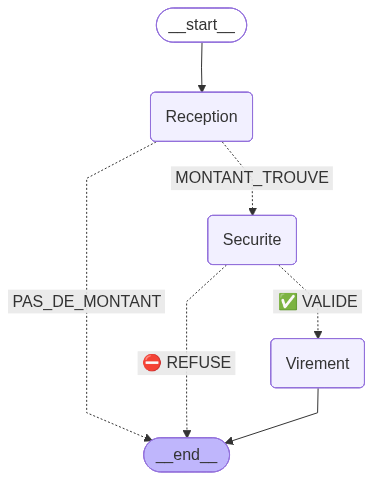

In [71]:
import re
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

# ============================================================
# 1. DÉFINITION DE LA MÉMOIRE (L'ÉTAT)
# ============================================================
# C'est le "Dossier Papier" qui va circuler de bureau en bureau.
# Chaque agent lit ce dossier, écrit dedans, et le passe au suivant.
class State(TypedDict):
    demande_utilisateur: str   # 🗣️ L'entrée brute (Ex: "Je veux 100 balles")
    montant_identifie: int     # 💰 La donnée structurée extraite par l'IA (Ex: 100)
    message_retour: str        # 💬 La réponse à afficher au client (si on doit lui parler)
    statut: str                # 🚦 L'état du dossier ("EN_COURS", "VALIDE", "REJETE")
    raison: str                # 📝 L'explication de la décision finale

# ============================================================
# 2. LES AGENTS (LES NOEUDS DU GRAPHE)
# ============================================================

def agent_reception(state: State):
    """
    🤖 AGENT 1 : LE RÉCEPTIONNISTE INTELLIGENT
    Rôle : Comprendre l'intention humaine et la traduire en données chiffrées.
    Particularité : Utilise le LLM pour distinguer "2 jambes" de "2 euros".
    """
    text_user = state['demande_utilisateur']
    print(f"   👂 [Réception] J'écoute : '{text_user}'")

    # --- ÉTAPE A : L'EXTRACTION ---
    # On configure le cerveau de l'IA avec des exemples (Few-Shot Learning)
    # pour qu'elle ne se fasse pas piéger par des nombres non-monétaires.
    prompt_extract = f"""
    Analyse la phrase suivante : "{text_user}".
    Ton but est d'extraire le MONTANT DU REMBOURSEMENT demandé.

    RÈGLES STRICTES :
    - Si l'utilisateur dit "je me suis cassé 2 jambes", le montant est 0 (ce n'est pas de l'argent).
    - Si l'utilisateur dit "ça fait 10 jours", le montant est 0.
    - Si l'utilisateur dit "je veux 200€", le montant est 200.
    - Si l'utilisateur dit "10 000 euros", le montant est 10000.

    TA RÉPONSE :
    Réponds UNIQUEMENT par le chiffre entier (sans devise, sans espace).
    Si aucun montant monétaire n'est clairement demandé, réponds 0.
    """

    response = llm.invoke(prompt_extract)
    # Nettoyage technique (au cas où l'IA laisserait un espace)
    content = response.content.strip().replace(" ", "")

    # Conversion sécurisée en nombre entier (Python)
    try:
        montant = int(content)
    except:
        montant = 0

    # --- ÉTAPE B : LA DÉCISION D'ORIENTATION ---

    # CAS 1 : On a trouvé de l'argent
    if montant > 0:
        print(f"   🤖 [IA] J'ai compris le montant financier : {montant}€")
        # On met à jour le dossier. Le champ 'message_retour' est vide car on ne parle pas au client, on avance.
        return {"montant_identifie": montant, "message_retour": ""}

    # CAS 2 : On n'a rien trouvé (ou c'est ambigu)
    else:
        print(f"   🤔 [IA] Pas de montant financier détecté. Je dois relancer le client.")

        # On redemande au LLM de générer une phrase polite pour demander le montant
        prompt_relance = f"""
        L'utilisateur a dit : "{text_user}".
        Il n'a pas donné de montant clair pour un remboursement.
        Réponds-lui poliment pour lui demander combien il souhaite se faire rembourser.
        Sois court et empathique.
        """
        msg = llm.invoke(prompt_relance).content

        # On inscrit 0 dans le dossier et on prépare le message pour l'utilisateur
        return {"montant_identifie": 0, "message_retour": msg}


def agent_fraude(state: State):
    """
    🕵️ AGENT 2 : LE CONTRÔLEUR DE GESTION
    Rôle : Appliquer les règles métier strictes.
    Note : Ici pas d'IA, c'est du code Python déterministe (If/Else).
    """
    montant = state['montant_identifie']
    print(f"   🕵️ [Fraude] Analyse du risque pour {montant}€...")

    # Règle métier : Pas d'automatisme au-dessus de 500€
    if montant > 500:
        return {"statut": "REJETE", "raison": "⚠️ Montant > 500€ (Validation humaine requise)."}

    return {"statut": "VALIDE", "raison": "✅ Montant < 500€ (Auto-validé)."}


def agent_tresorerie(state: State):
    """
    💸 AGENT 3 : LE PAYEUR
    Rôle : Exécuter l'action finale (simulée).
    """
    print(f"   💸 [Finance] Virement de {state['montant_identifie']}€ effectué.")
    return {"raison": "VIREMENT EFFECTUÉ"}


# ============================================================
# 3. CONSTRUCTION DU GRAPHE (L'ORCHESTRATION)
# ============================================================
# C'est ici qu'on relie les agents entre eux avec des tuyaux.

workflow = StateGraph(State)

# A. On déclare nos agents (Les stations de travail)
workflow.add_node("Reception", agent_reception)
workflow.add_node("Securite", agent_fraude)
workflow.add_node("Virement", agent_tresorerie)

# B. On définit l'entrée du labyrinthe
workflow.set_entry_point("Reception")

# C. LOGIQUE DE NAVIGATION (LES AIGUILLAGES)

# Aiguillage 1 : Après la réception, où va-t-on ?
def routeur_reception(state):
    # C'est la fonction "Feu Tricolore" qui regarde le dossier
    if state["montant_identifie"] == 0:
        return "PAS_DE_MONTANT" # -> On sortira vers l'utilisateur
    return "MONTANT_TROUVE"     # -> On ira vers la fraude

workflow.add_conditional_edges(
    "Reception",           # Départ
    routeur_reception,     # Fonction de décision
    {
        # Mapping : "Résultat de la fonction" : "Destination"
        "PAS_DE_MONTANT": END,       # FIN DU TOUR : On rend la main à l'utilisateur pour qu'il réponde
        "MONTANT_TROUVE": "Securite" # CONTINUER : On passe le dossier à l'agent sécurité
    }
)

# Aiguillage 2 : Après la sécurité, on paye ou on ferme ?
def routeur_securite(state):
    if state["statut"] == "VALIDE":
        return "✅ VALIDE"
    return "⛔ REFUSE"

workflow.add_conditional_edges(
    "Securite",
    routeur_securite,
    {
        "✅ VALIDE": "Virement", # Si validé -> On va payer
        "⛔ REFUSE": END         # Si refusé -> On arrête tout
    }
)

# Dernier lien simple : Après le virement, c'est fini.
workflow.add_edge("Virement", END)

# D. Compilation finale
app_graph = workflow.compile()

print("✅ Agent Conversationnel prêt.")

# Visualisation (Optionnelle)
try:
    display(Image(app_graph.get_graph().draw_mermaid_png()))
except:
    pass

In [72]:
print("--- DÉMARRAGE DE L'AGENT CONVERSATIONNEL (Tapez 'q' pour quitter) ---\n")
print("💡 SCÉNARIO : Cette fois-ci un LLM va juste vous écouter jusqu'à ce que vous énonciez le montant souhaité.")
print(" A ce moment-là il enclenchera une série d'étapes déterminées par le graph : contrôle du montant -> paiement ou renvoi à un humain.")
print("\n")
print("🤖 IA : Bonjour, je suis l'assistant indemnisation. Dites-moi quel est votre souci.")

while True:
    user_input = input("\n👤 VOUS : ")
    if user_input.lower() in ['q', 'exit']: break

    # Exécution du graphe
    resultat = app_graph.invoke({
        "demande_utilisateur": user_input,
        "montant_identifie": 0,
        "statut": "INIT",
        "raison": "",
        "message_retour": ""
    })

    # ANALYSE DU RÉSULTAT DU GRAPHE

    # Cas 1 : L'agent a une question (pas de montant trouvé)
    if resultat['montant_identifie'] == 0:
        print(f"🤖 IA : {resultat['message_retour']}")
        continue # On repart au début de la boucle while pour attendre la réponse du client

    # Cas 2 : Le processus est allé au bout (Validé ou Rejeté)
    if resultat['statut'] == "VALIDE":
        print(f"\n✅ SUCCÈS : {resultat['raison']}")
        print("🤖 IA : Dossier clos. Autre chose ?")
    elif resultat['statut'] == "REJETE":
        print(f"\n❌ ÉCHEC : {resultat['raison']}")
        print("🤖 IA : Dossier clos. Autre chose ?")

--- DÉMARRAGE DE L'AGENT CONVERSATIONNEL (Tapez 'q' pour quitter) ---

💡 SCÉNARIO : Cette fois-ci un LLM va juste vous écouter jusqu'à ce que vous énonciez le montant souhaité.
 A ce moment-là il enclenchera une série d'étapes déterminées par le graph : contrôle du montant -> paiement ou renvoi à un humain.


🤖 IA : Bonjour, je suis l'assistant indemnisation. Dites-moi quel est votre souci.

👤 VOUS : je me suis blessé
   👂 [Réception] J'écoute : 'je me suis blessé'
   🤔 [IA] Pas de montant financier détecté. Je dois relancer le client.
🤖 IA : Je suis désolé d'apprendre que vous vous êtes blessé. Pourriez-vous me dire quel montant vous souhaitez pour le remboursement ? Merci.

👤 VOUS : 400€ environ
   👂 [Réception] J'écoute : '400€ environ'
   🤖 [IA] J'ai compris le montant financier : 400€
   🕵️ [Fraude] Analyse du risque pour 400€...
   💸 [Finance] Virement de 400€ effectué.

✅ SUCCÈS : VIREMENT EFFECTUÉ
🤖 IA : Dossier clos. Autre chose ?

👤 VOUS : q
